In [12]:

import pandas as pd

# Load CSVs
df1 = pd.read_csv(r"C:\Users\admin\morocco_supermarkets.csv")
df2 = pd.read_csv(r"C:\Users\admin\morocco_supermarkets11.csv")

# Merge
df = pd.concat([df1, df2], ignore_index=True)

# Reset index
df = df.reset_index(drop=True)

# Save final dataset
df.to_csv("morocco_supermarckets_final.csv", index=False, encoding="utf-8-sig")

# Check
print(df.shape)
print(df.head())

(745, 9)
                 name        city        lat       lon         type  \
0             Marjane  Casablanca  33.544670 -7.639958  supermarket   
1               Acima  Casablanca  33.594538 -7.595292  supermarket   
2             Marjane  Casablanca  33.574692 -7.708105  supermarket   
3  Supermarché Mamoun  Casablanca  33.587931 -7.639393  supermarket   
4      Marjane Market  Casablanca  33.594818 -7.651587  supermarket   

            brand phone website         opening_hours  
0         Marjane   NaN     NaN  PH,Mo-Su 09:00-22:00  
1             NaN   NaN     NaN     Mo-Su 10:00-22:00  
2         Marjane   NaN     NaN                   NaN  
3             NaN   NaN     NaN                   NaN  
4  Marjane Market   NaN     NaN                   NaN  


In [13]:
null_counts = df.isnull().sum().sort_values(ascending=False)
print(null_counts)

website          726
phone            719
opening_hours    686
brand            572
name               0
city               0
lat                0
lon                0
type               0
dtype: int64


In [15]:
import pandas as pd

# =========================
# 1. CHARGEMENT DES CSV
# =========================
restaurants = pd.read_csv(r"C:\Users\admin\morocco_restaurants_final.csv")
cafes = pd.read_csv(r"C:\Users\admin\morocco_cafes_final.csv")
atm = pd.read_csv(r"C:\Users\admin\morocco_atm_bank_final.csv")
pharmacies = pd.read_csv(r"C:\Users\admin\morocco_pharmacies_final.csv")
supermarkets = pd.read_csv(r"C:\Users\admin\morocco_supermarckets_final.csv")
# =========================
# 2. NORMALISATION COLONNES
# =========================
def clean_df(df, type_name):
    return pd.DataFrame({
        "name": df.get("name"),
        "city": df.get("city"),
        "lat": df.get("lat"),
        "lon": df.get("lon"),
        "type": type_name
    })

# =========================
# 3. STANDARDISATION
# =========================
df_restaurants = clean_df(restaurants, "restaurant")
df_cafes = clean_df(cafes, "cafe")
df_atm = clean_df(atm, "atm")
df_pharmacies = clean_df(pharmacies, "pharmacy")
df_supermarkets = clean_df(supermarkets, "supermarket")

# =========================
# 4. CONCATENATION
# =========================
df_final = pd.concat([
    df_restaurants,
    df_cafes,
    df_atm,
    df_pharmacies,
    df_supermarkets
], ignore_index=True)

# =========================
# =========================
# 6. RESULTAT
# =========================
print("📊 Dataset final :", df_final.shape)
print(df_final.head())

# =========================
# 7. EXPORT CSV
# =========================
df_final.to_csv("morocco_aservices_dataset_final.csv", index=False, encoding="utf-8-sig")

print("\n✅ Dataset fusionné sauvegardé !")

📊 Dataset final : (12154, 5)
        name        city        lat       lon        type
0  La Bodega  Casablanca  33.595219 -7.611573  restaurant
1   La Sqala  Casablanca  33.602848 -7.619212  restaurant
2  Pizza Hut  Casablanca  33.592847 -7.597267  restaurant
3  Chez Pépé  Casablanca  33.595533 -7.645483  restaurant
4  Paradisio  Casablanca  33.593828 -7.596918  restaurant

✅ Dataset fusionné sauvegardé !


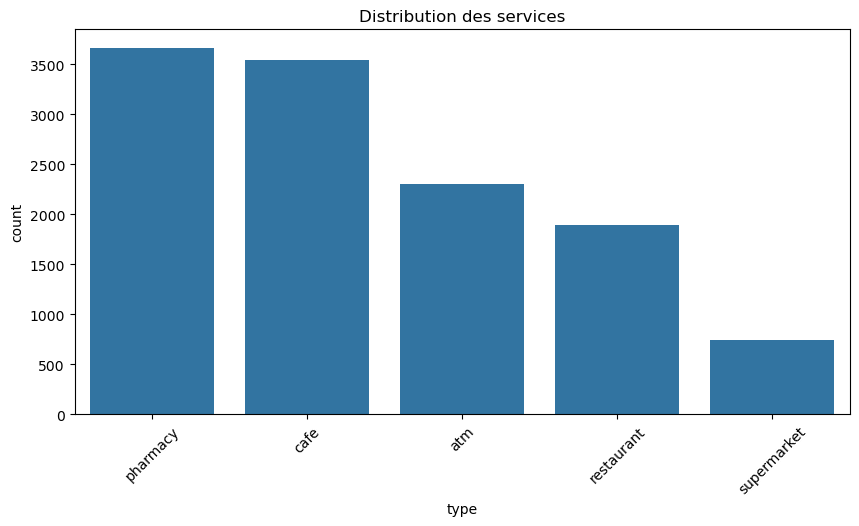

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\admin\morocco_aservices_dataset_final.csv")

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index)

plt.title("Distribution des services")
plt.xticks(rotation=45)
plt.show()

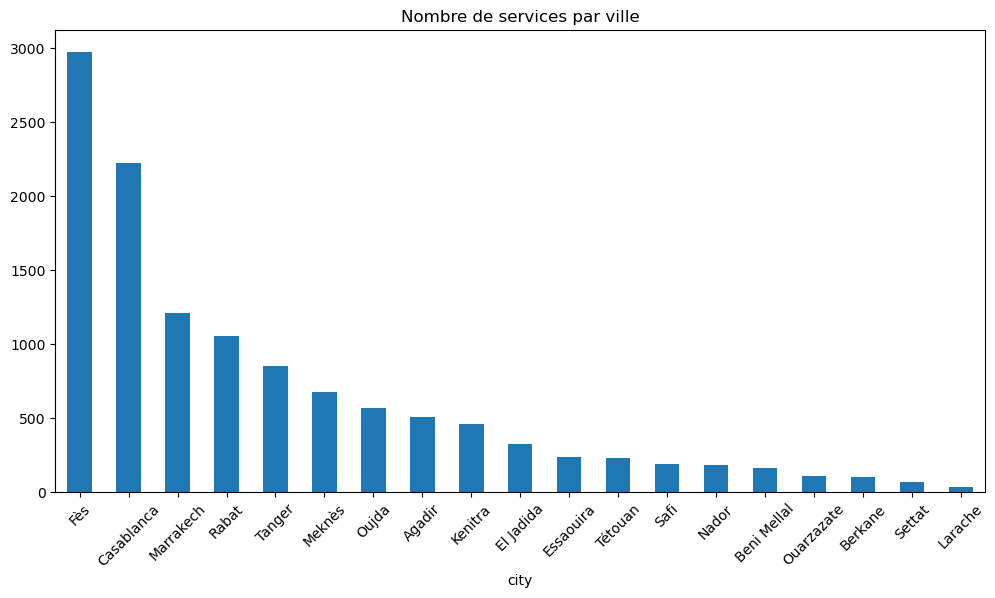

In [17]:
plt.figure(figsize=(12,6))
df["city"].value_counts().plot(kind="bar")

plt.title("Nombre de services par ville")
plt.xticks(rotation=45)
plt.show()

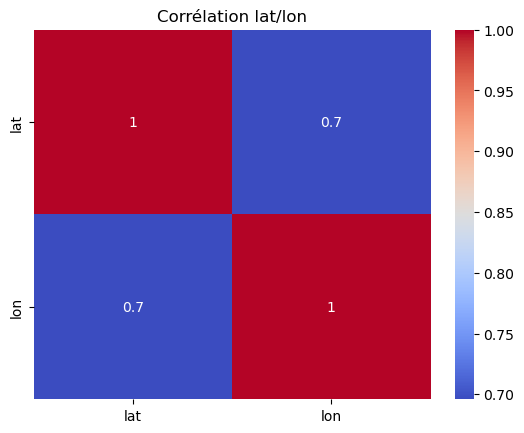

In [18]:
sns.heatmap(df[["lat","lon"]].corr(), annot=True, cmap="coolwarm")
plt.title("Corrélation lat/lon")
plt.show()

In [22]:
import folium

# centre Maroc
map_morocco = folium.Map(location=[31.8, -7.1], zoom_start=6)

for _, row in df.sample(1000).iterrows():  # sample pour performance
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=f"{row['name']} ({row['type']})"
    ).add_to(map_morocco)

map_morocco

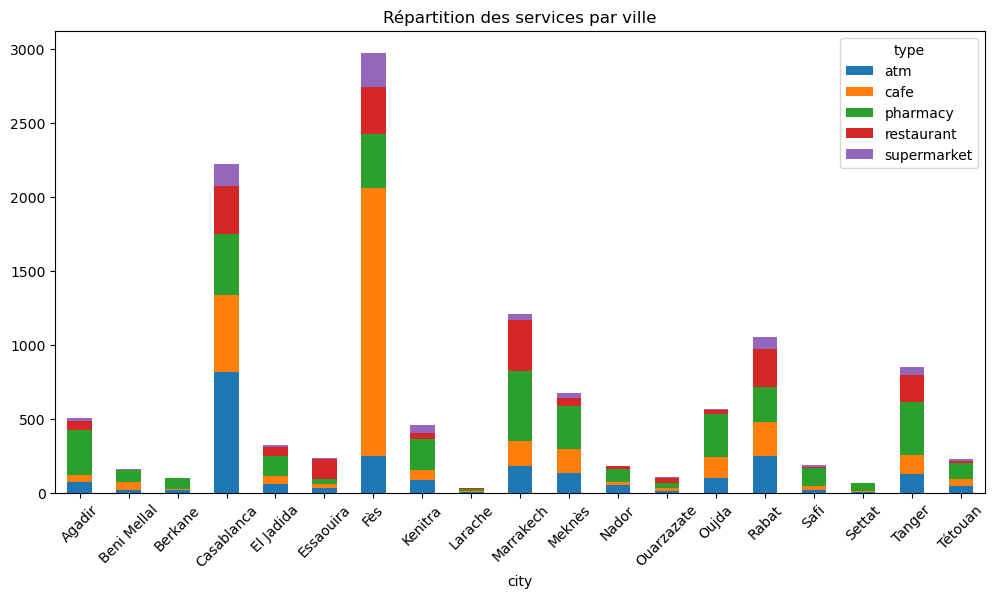

In [23]:
pivot = pd.crosstab(df["city"], df["type"])

pivot.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Répartition des services par ville")
plt.xticks(rotation=45)
plt.show()

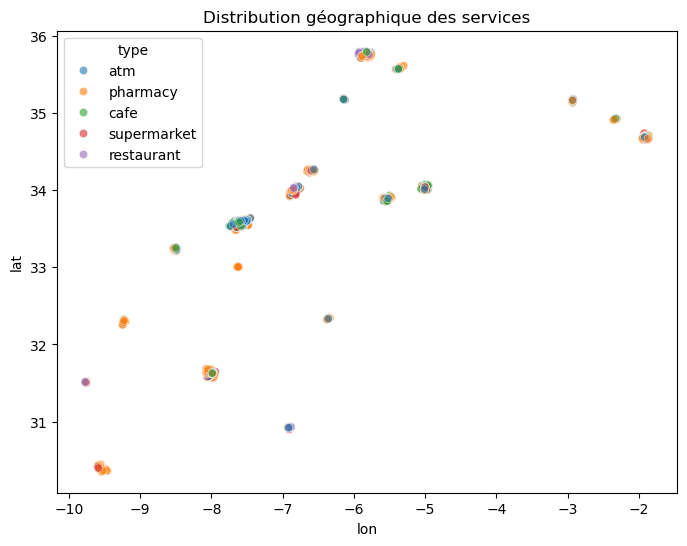

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(2000),
    x="lon",
    y="lat",
    hue="type",
    alpha=0.6
)

plt.title("Distribution géographique des services")
plt.show()

In [5]:
from flask import Flask, request, jsonify, render_template
import pandas as pd
import numpy as np
import requests
import pickle

app = Flask(__name__)

df = pd.read_csv(r"C:\Users\admin\morocco_aservices_dataset_final.csv")

df = df.dropna(subset=["lat", "lon", "name"])
df["type"] = df["type"].str.lower()

# =========================
# HAVERSINE
# =========================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)

    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# =========================
# MODEL CLASS
# =========================
class RecommenderModel:

    def __init__(self, df):
        self.df = df.copy()

    def recommend(self, lat, lon, service_type, k=3):

        data = self.df[self.df["type"] == service_type].copy()

        if data.empty:
            return data

        # distance
        data["distance"] = data.apply(
            lambda row: haversine(lat, lon, row["lat"], row["lon"]),
            axis=1
        )

        # score simple
        data["score"] = 1 / (1 + data["distance"])

        return data.sort_values("score", ascending=False).head(k)

# =========================
# TRAIN MODEL
# =========================
model = RecommenderModel(df)

# =========================
# SAVE MODEL
# =========================
with open("recommender_services_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model trained & saved!")

✅ Model trained & saved!


In [6]:
from flask import Flask, request, jsonify, render_template
import pickle
import numpy as np
from recommender import RecommenderModel

app = Flask(__name__)

# =========================
# LOAD MODEL
# =========================
with open("recommender_services_model.pkl", "rb") as f:
    model = pickle.load(f)

# =========================
# HOME PAGE (HTML)
# =========================
@app.route("/")
def home():
    return render_template("API_Proches_Services.html")

# =========================
# RECOMMEND API
# =========================
@app.route("/recommend")
def recommend():

    lat = request.args.get("lat")
    lon = request.args.get("lon")
    service = request.args.get("type")

    # =========================
    # VALIDATION (IMPORTANT)
    # =========================
    if not lat or not lon or lat == "null" or lon == "null":
        return jsonify({"error": "missing coordinates"}), 400

    if not service:
        return jsonify({"error": "missing type"}), 400

    try:
        lat = float(lat)
        lon = float(lon)
    except:
        return jsonify({"error": "invalid coordinates"}), 400

    # =========================
    # MODEL PREDICTION
    # =========================
    results = model.recommend(lat, lon, service.lower())

    if results is None or len(results) == 0:
        return jsonify([])

    return jsonify(results.to_dict(orient="records"))
# RUN APP
# =========================
if __name__ == "__main__":
    app.run(
        host="127.0.0.1",
        port=8000,
        debug=False
    )

ModuleNotFoundError: No module named 'recommender'